In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import pandas as pd

project_root = Path("/Users/najmanuur/Desktop/credit-risk-prediction")

input_file = project_root / "data" / "processed" / "credit_default_clean.csv"

df = pd.read_csv(input_file)

print("Loaded:", input_file)
print("Shape:", df.shape)

df.head()

Loaded: /Users/najmanuur/Desktop/credit-risk-prediction/data/processed/credit_default_clean.csv
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


1. Target Variable Analysis

The target variable indicates whether a customer defaulted on their payment in the following month.

Before exploring the predictor variables, we examine the distribution of the target to determine whether the dataset is balanced.

In [4]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [7]:
target = "default payment next month"

df[target].value_counts()

default payment next month
0    23364
1     6636
Name: count, dtype: int64

In [8]:
df[target].value_counts(normalize=True).mul(100).round(2)

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64

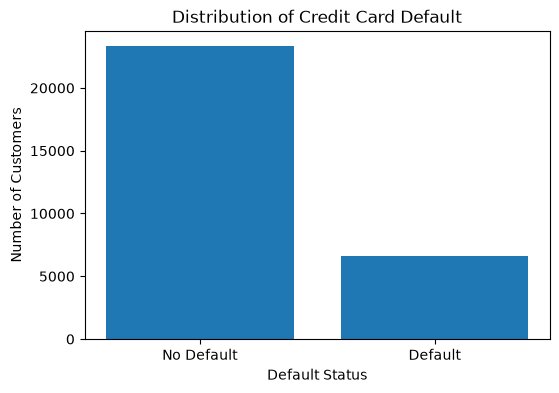

In [9]:
target_counts = df[target].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Default", "Default"],
    target_counts.values
)

plt.title("Distribution of Credit Card Default")
plt.ylabel("Number of Customers")
plt.xlabel("Default Status")

plt.show()

Interpretation

The dataset is moderately imbalanced. Approximately 77.88% of customers did not default, while 22.12% defaulted.

This means that a model could achieve relatively high accuracy by predicting the majority class, so accuracy alone will not be sufficient for evaluating model performance.

Later, metrics such as precision, recall, F1-score, ROC-AUC, and the confusion matrix should also be considered, with particular attention given to identifying customers who actually default.

## 2. Customer Demographics

This section explores the demographic characteristics of customers, including age, sex, education, and marital status, and examines how these characteristics relate to default behaviour.

### 2.1 Age Distribution

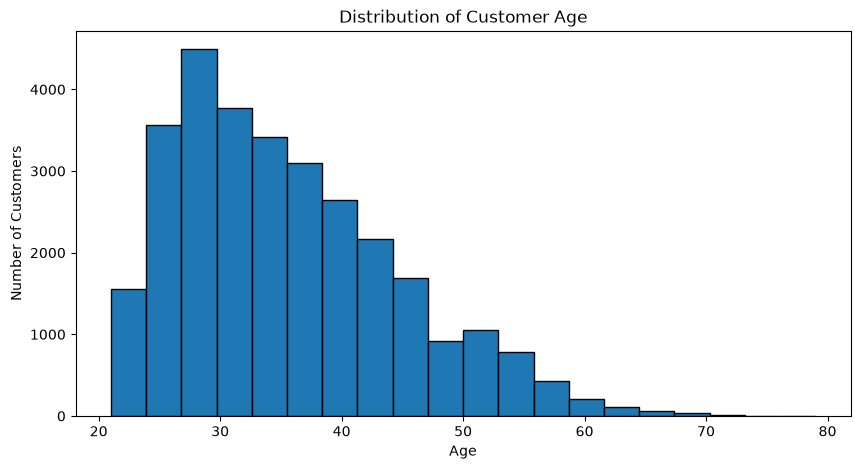

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(df["AGE"], bins=20, edgecolor="black")

plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [11]:
df["AGE"].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

In [12]:
df.groupby(target)["AGE"].agg(["mean", "median", "std"])

,mean,median,std
default payment next month,,,
0,35.417266,34.0,9.077355
1,35.725738,34.0,9.693438


In [13]:
df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=[20, 29, 39, 49, 59, 69, 80],
    labels=["20-29", "30-39", "40-49", "50-59", "60-69", "70+"]
)

age_default = (
    df.groupby("AGE_GROUP", observed=False)[target]
      .mean()
      .mul(100)
)

age_default

AGE_GROUP
20-29    22.842587
30-39    20.252714
40-49    22.973391
50-59    24.861170
60-69    28.343949
70+      28.000000
Name: default payment next month, dtype: float64

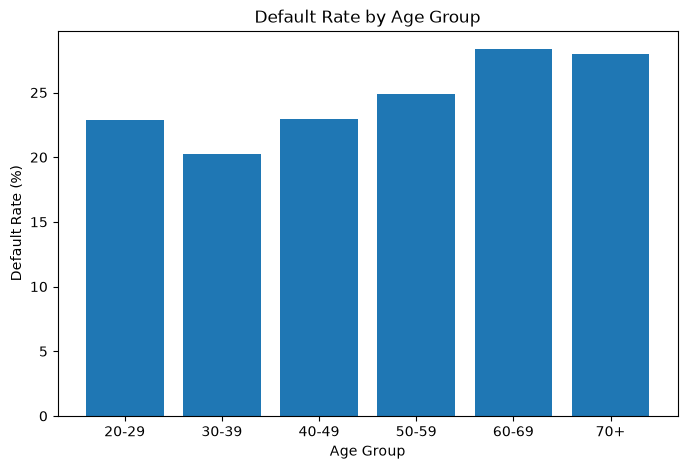

In [14]:
plt.figure(figsize=(8, 5))

plt.bar(age_default.index.astype(str), age_default.values)

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate (%)")

plt.show()

In [15]:
df.groupby(target)["AGE"].agg(["mean", "median", "std"])

,mean,median,std
default payment next month,,,
0,35.417266,34.0,9.077355
1,35.725738,34.0,9.693438


In [16]:
age_default

AGE_GROUP
20-29    22.842587
30-39    20.252714
40-49    22.973391
50-59    24.861170
60-69    28.343949
70+      28.000000
Name: default payment next month, dtype: float64

### Interpretation

The average age of customers who defaulted (35.73 years) is very similar to that of customers who did not default (35.42 years). Both groups have a median age of 34, suggesting that age alone does not strongly separate defaulters from non-defaulters.

However, the default rate varies across age groups. Customers aged 30–39 have the lowest default rate at approximately 20.25%. The rate generally increases among older customers, reaching approximately 28.34% for customers aged 60–69 and 28.00% for those aged 70 and above.

This suggests that age may still contain useful predictive information, particularly when considered in age groups or alongside other variables. The oldest groups may contain relatively few observations, so their higher default rates should be interpreted cautiously.

In [17]:
df["SEX"].value_counts().sort_index()

SEX
1    11888
2    18112
Name: count, dtype: int64

In [18]:
sex_default = (
    df.groupby("SEX")[target]
      .agg(["count", "mean"])
)

sex_default["default_rate"] = sex_default["mean"] * 100

sex_default

,count,mean,default_rate
SEX,,,
1,11888,0.241672,24.167227
2,18112,0.207763,20.776281


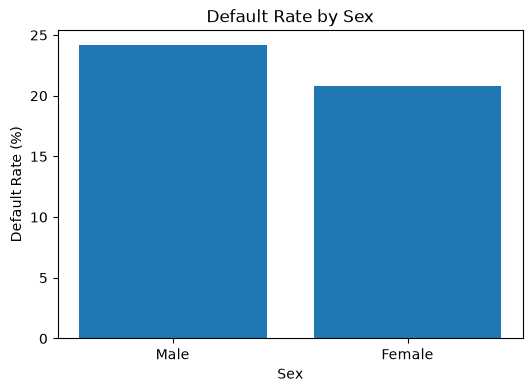

In [19]:
sex_rates = sex_default["default_rate"]

plt.figure(figsize=(6, 4))

plt.bar(
    ["Male", "Female"],
    sex_rates.values
)

plt.title("Default Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Default Rate (%)")

plt.show()

### Interpretation

Female customers represent the larger group in the dataset, with 18,112 observations compared with 11,888 male customers.

The default rate differs between the two groups. Male customers have a default rate of approximately 24.17%, compared with 20.78% for female customers.

This indicates an association between sex and default behaviour in this dataset, with male customers showing a higher observed default rate. However, this descriptive relationship does not establish that sex itself causes a higher risk of default, as the difference may also be associated with other customer characteristics.

In [20]:
df["EDUCATION"].value_counts().sort_index()

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [21]:
education_default = (
    df.groupby("EDUCATION")[target]
      .agg(["count", "mean"])
)

education_default["default_rate"] = education_default["mean"] * 100

education_default

,count,mean,default_rate
EDUCATION,,,
0,14,0.000000,0.000000
1,10585,0.192348,19.234766
2,14030,0.237349,23.734854
3,4917,0.251576,25.157616
4,123,0.056911,5.691057
5,280,0.064286,6.428571
6,51,0.156863,15.686275


In [22]:
education_labels = {
    0: "Other/Unknown",
    1: "Graduate School",
    2: "University",
    3: "High School",
    4: "Other",
    5: "Other/Unknown",
    6: "Other/Unknown"
}

df["EDUCATION_GROUP"] = df["EDUCATION"].map(education_labels)

education_summary = (
    df.groupby("EDUCATION_GROUP")[target]
      .agg(["count", "mean"])
)

education_summary["default_rate"] = education_summary["mean"] * 100

education_summary.sort_values("default_rate", ascending=False)

,count,mean,default_rate
EDUCATION_GROUP,,,
High School,4917,0.251576,25.157616
University,14030,0.237349,23.734854
Graduate School,10585,0.192348,19.234766
Other/Unknown,345,0.075362,7.536232
Other,123,0.056911,5.691057


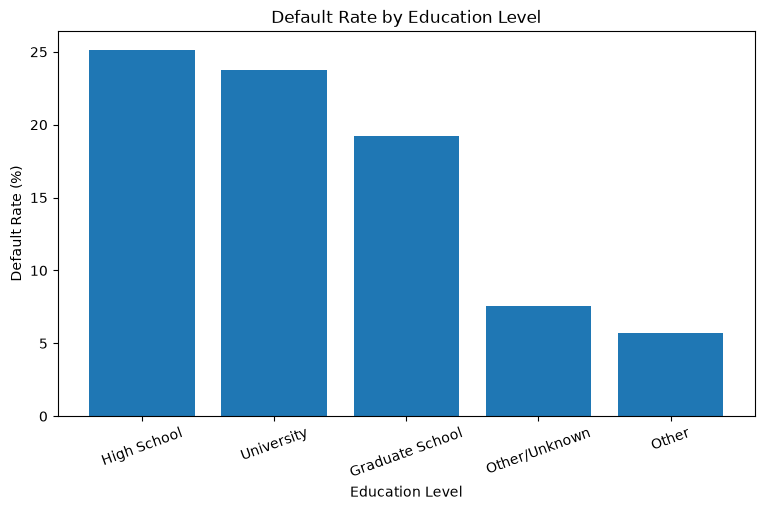

In [23]:
education_rates = (
    education_summary["default_rate"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

plt.bar(education_rates.index, education_rates.values)

plt.title("Default Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)

plt.show()

### Interpretation

Education level shows differences in observed default rates. High school customers have the highest default rate among the main education categories at approximately 25.16%, followed by university customers at 23.73% and graduate school customers at 19.23%.

Several additional education codes (0, 5, and 6) appear in the dataset but contain relatively few observations and are not part of the main documented education categories. These were therefore grouped as "Other/Unknown" for clearer analysis.

Overall, the results suggest that education may contain useful predictive information, although categories with small sample sizes should be interpreted cautiously.

In [24]:
df["MARRIAGE"].value_counts().sort_index()

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

In [25]:
marriage_default = (
    df.groupby("MARRIAGE")[target]
      .agg(["count", "mean"])
)

marriage_default["default_rate"] = marriage_default["mean"] * 100

marriage_default

,count,mean,default_rate
MARRIAGE,,,
0,54,0.092593,9.259259
1,13659,0.234717,23.471704
2,15964,0.209283,20.928339
3,323,0.260062,26.006192


In [26]:
marriage_labels = {
    0: "Unknown",
    1: "Married",
    2: "Single",
    3: "Other"
}

df["MARRIAGE_GROUP"] = df["MARRIAGE"].map(marriage_labels)

marriage_summary = (
    df.groupby("MARRIAGE_GROUP")[target]
      .agg(["count", "mean"])
)

marriage_summary["default_rate"] = marriage_summary["mean"] * 100

marriage_summary

,count,mean,default_rate
MARRIAGE_GROUP,,,
Married,13659,0.234717,23.471704
Other,323,0.260062,26.006192
Single,15964,0.209283,20.928339
Unknown,54,0.092593,9.259259


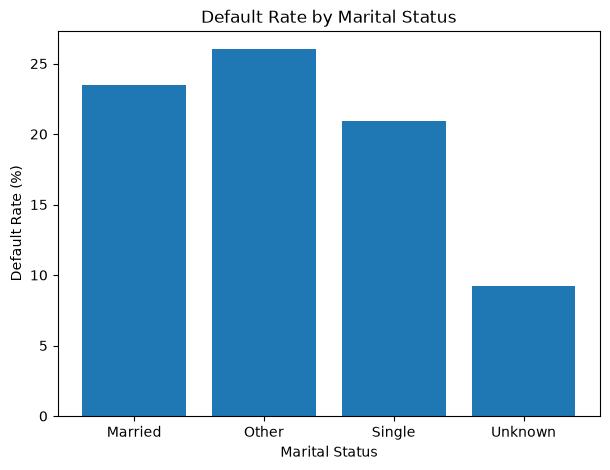

In [27]:
plt.figure(figsize=(7, 5))

plt.bar(
    marriage_summary.index,
    marriage_summary["default_rate"]
)

plt.title("Default Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Default Rate (%)")

plt.show()

### Interpretation

Marital status shows some variation in default behaviour. Married customers have a default rate of approximately 23.47%, compared with 20.93% among single customers.

Customers classified as "Other" have the highest observed default rate at approximately 26.01%. However, this category contains only 323 customers, so the result should be interpreted cautiously.

The undocumented category (code 0) contains only 54 observations and has a default rate of approximately 9.26%. Given its very small size and unclear meaning, it should not be interpreted as evidence of lower credit risk.

Overall, marital status may provide some predictive information, although the differences between the two major groups are relatively modest.

## 3. Credit and Repayment Behaviour

This section examines customers' credit limits, repayment history, bill amounts, and previous payments. These variables are expected to be particularly relevant to predicting future default because they directly describe customers' historical credit behaviour.

### 3.1 Credit Limit

In [29]:
df["LIMIT_BAL"].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

In [30]:
df.groupby(target)["LIMIT_BAL"].agg(
    ["count", "mean", "median", "std"]
).round(2)

,count,mean,median,std
default payment next month,,,,
0,23364,178099.73,150000.0,131628.36
1,6636,130109.66,90000.0,115378.54


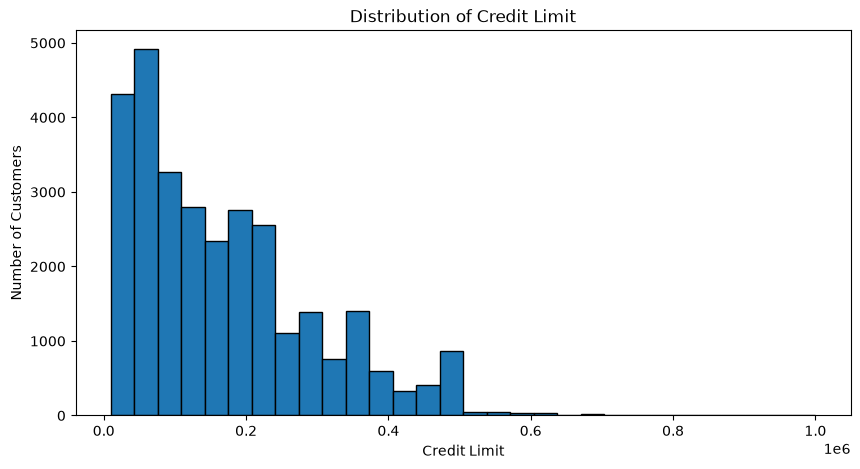

In [31]:
plt.figure(figsize=(10, 5))

plt.hist(df["LIMIT_BAL"], bins=30, edgecolor="black")

plt.title("Distribution of Credit Limit")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")

plt.show()

In [32]:
df["LIMIT_GROUP"] = pd.qcut(
    df["LIMIT_BAL"],
    q=5,
    duplicates="drop"
)

limit_default = (
    df.groupby("LIMIT_GROUP", observed=False)[target]
      .agg(["count", "mean"])
)

limit_default["default_rate"] = limit_default["mean"] * 100

limit_default

,count,mean,default_rate
LIMIT_GROUP,,,
"(9999.999, 50000.0]",7676,0.317874,31.787389
"(50000.0, 100000.0]",4822,0.257984,25.798424
"(100000.0, 180000.0]",6123,0.198595,19.859546
"(180000.0, 270000.0]",5421,0.168604,16.860358
"(270000.0, 1000000.0]",5958,0.137966,13.796576


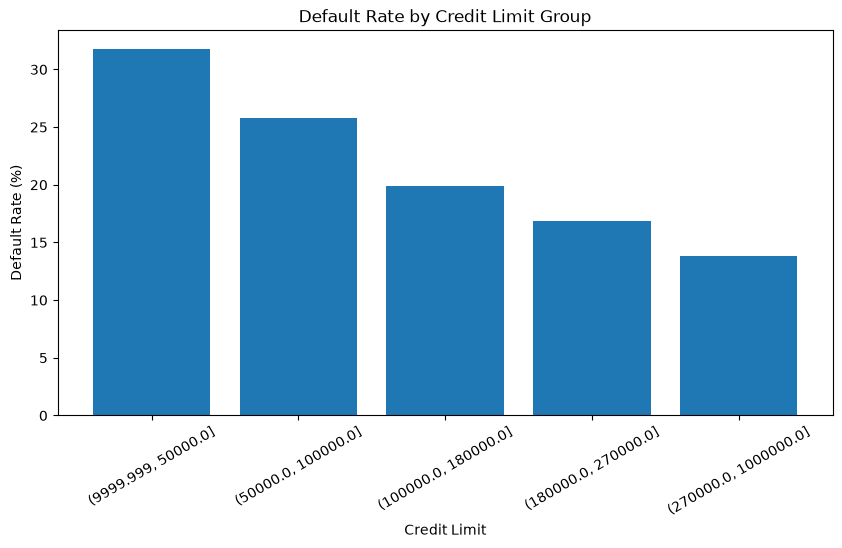

In [33]:
plt.figure(figsize=(10, 5))

plt.bar(
    limit_default.index.astype(str),
    limit_default["default_rate"]
)

plt.title("Default Rate by Credit Limit Group")
plt.xlabel("Credit Limit")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=30)

plt.show()

### Interpretation

Credit limit shows a clear relationship with default behaviour. Customers in the lowest credit-limit group have the highest default rate at approximately 31.79%, while customers in the highest credit-limit group have the lowest default rate at approximately 13.80%.

The default rate decreases consistently as the credit limit increases. Customers with limits above 270,000 have less than half the observed default rate of customers with limits of 50,000 or below.

This suggests that `LIMIT_BAL` is likely to be an important predictor of default. However, the relationship should not be interpreted as causal, since credit limits themselves may reflect factors such as income, previous credit history, and the lender's assessment of customer risk.

In [34]:
[col for col in df.columns if col.startswith("PAY")]

['PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6']

### 3.2 Repayment Status

The repayment-status variables describe customers' payment behaviour over the previous six months. Higher positive values indicate longer payment delays.

Because repayment history directly reflects whether customers have previously struggled to make payments on time, these variables may be important predictors of future default.

In [35]:
pay_status_cols = [
    "PAY_0", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

df[pay_status_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.0,0.0,0.0,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.0,0.0,0.0,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.0,0.0,0.0,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.0,0.0,0.0,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.0,0.0,0.0,8.0
PAY_6,30000.0,-0.291100,1.149988,-2.0,-1.0,0.0,0.0,8.0


In [36]:
df["PAY_0"].value_counts().sort_index()

PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

In [37]:
pay0_default = (
    df.groupby("PAY_0")[target]
      .agg(["count", "mean"])
)

pay0_default["default_rate"] = pay0_default["mean"] * 100

pay0_default

,count,mean,default_rate
PAY_0,,,
-2,2759,0.132294,13.229431
-1,5686,0.167781,16.778051
0,14737,0.128113,12.811291
1,3688,0.339479,33.947939
2,2667,0.691414,69.141357
3,322,0.757764,75.776398
4,76,0.684211,68.421053
5,26,0.500000,50.000000
6,11,0.545455,54.545455


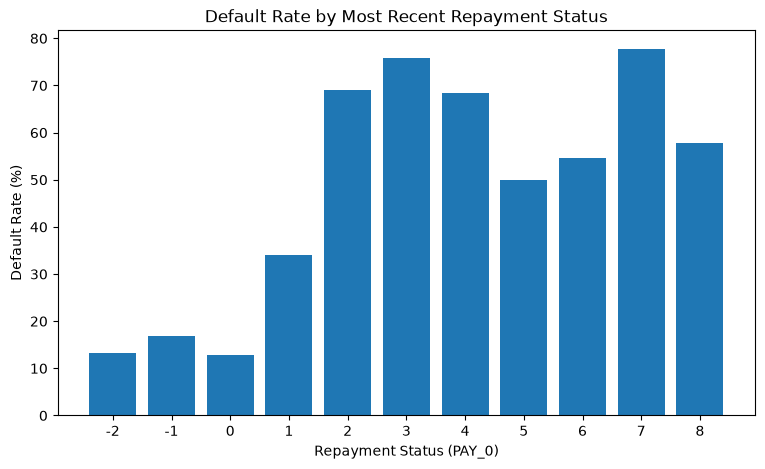

In [38]:
plt.figure(figsize=(9, 5))

plt.bar(
    pay0_default.index.astype(str),
    pay0_default["default_rate"]
)

plt.title("Default Rate by Most Recent Repayment Status")
plt.xlabel("Repayment Status (PAY_0)")
plt.ylabel("Default Rate (%)")

plt.show()

### Interpretation

The most recent repayment status shows a strong relationship with default.

Customers with a repayment status of 0 have a default rate of approximately 12.81%. The default rate increases sharply to 33.95% for status 1 and 69.14% for status 2. Customers with more severe delays generally continue to show very high default rates.

This is substantially stronger than the relationships observed for the demographic variables, suggesting that recent repayment behaviour is likely to be one of the most important predictors of future default.

Some of the highest repayment-status categories contain very few customers, so their individual default rates are less stable and should be interpreted cautiously.

In [40]:
repayment_summary = []

for col in pay_status_cols:
    delayed = df[col] > 0
    
    repayment_summary.append({
        "month": col,
        "not_delayed_default_rate": df.loc[~delayed, target].mean() * 100,
        "delayed_default_rate": df.loc[delayed, target].mean() * 100
    })

repayment_summary = pd.DataFrame(repayment_summary)

repayment_summary

,month,not_delayed_default_rate,delayed_default_rate
0,PAY_0,13.834009,50.293341
1,PAY_2,16.274157,55.790897
2,PAY_3,17.194711,52.266793
3,PAY_4,17.957720,53.532764
4,PAY_5,18.448505,55.559299
5,PAY_6,18.665726,52.322183


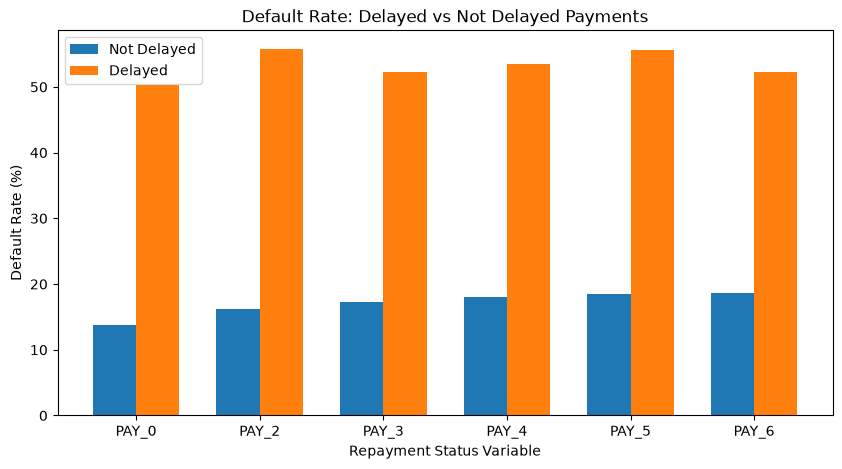

In [41]:
plt.figure(figsize=(10, 5))

x = np.arange(len(repayment_summary))
width = 0.35

plt.bar(
    x - width/2,
    repayment_summary["not_delayed_default_rate"],
    width,
    label="Not Delayed"
)

plt.bar(
    x + width/2,
    repayment_summary["delayed_default_rate"],
    width,
    label="Delayed"
)

plt.xticks(x, repayment_summary["month"])
plt.xlabel("Repayment Status Variable")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate: Delayed vs Not Delayed Payments")
plt.legend()

plt.show()

### Repayment History Interpretation

Payment delays are strongly associated with future default across all six repayment periods.

Customers with delayed payments have default rates of approximately 50–56%, compared with around 14–19% among customers without recorded delays.

The most recent repayment status (`PAY_0`) shows a particularly strong difference, with a default rate of approximately 50.29% among customers with a delay compared with 13.83% among those without one.

The consistency of this pattern across all six months suggests that repayment history is likely to be one of the strongest groups of predictors in the dataset.

### 3.3 Bill Amounts

The bill amount variables represent customers' outstanding statement balances over the previous six months. This section examines their distributions and whether bill balances differ between customers who defaulted and those who did not.

In [42]:
bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

df[bill_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


In [43]:
bill_by_default = (
    df.groupby(target)[bill_cols]
      .mean()
      .T
)

bill_by_default.columns = ["No Default", "Default"]

bill_by_default.round(2)

,No Default,Default
BILL_AMT1,51994.23,48509.16
BILL_AMT2,49717.44,47283.62
BILL_AMT3,47533.37,45181.60
BILL_AMT4,43611.17,42036.95
BILL_AMT5,40530.45,39540.19
BILL_AMT6,39042.27,38271.44


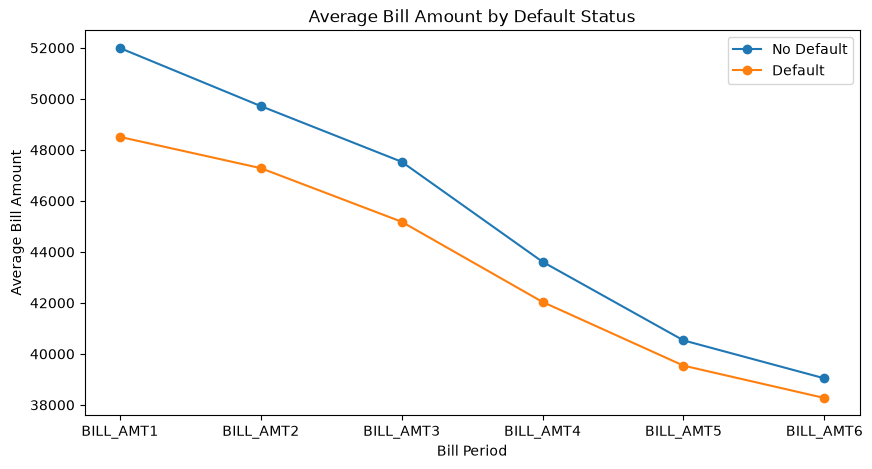

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    bill_by_default.index,
    bill_by_default["No Default"],
    marker="o",
    label="No Default"
)

plt.plot(
    bill_by_default.index,
    bill_by_default["Default"],
    marker="o",
    label="Default"
)

plt.title("Average Bill Amount by Default Status")
plt.xlabel("Bill Period")
plt.ylabel("Average Bill Amount")
plt.legend()

plt.show()

### Bill Amount Interpretation

Average bill amounts are slightly higher for customers who did not default across all six billing periods.

For example, the average most recent bill (`BILL_AMT1`) is approximately 51,994 for non-defaulting customers compared with 48,509 for customers who defaulted. A similar pattern is observed across the remaining billing periods.

The differences between the two groups are relatively modest, suggesting that the absolute size of a customer's bill alone may not be a strong indicator of default risk.

This also suggests that bill amounts may become more informative when considered relative to credit limits or alongside actual payment behaviour rather than in isolation.

### 3.4 Previous Payment Amounts

The payment amount variables represent the amounts customers paid during the previous six months. Comparing payment behaviour between defaulters and non-defaulters may reveal differences in customers' ability or willingness to repay outstanding balances.

In [45]:
payment_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

payment_by_default = (
    df.groupby(target)[payment_cols]
      .mean()
      .T
)

payment_by_default.columns = ["No Default", "Default"]

payment_by_default.round(2)

,No Default,Default
PAY_AMT1,6307.34,3397.04
PAY_AMT2,6640.47,3388.65
PAY_AMT3,5753.50,3367.35
PAY_AMT4,5300.53,3155.63
PAY_AMT5,5248.22,3219.14
PAY_AMT6,5719.37,3441.48


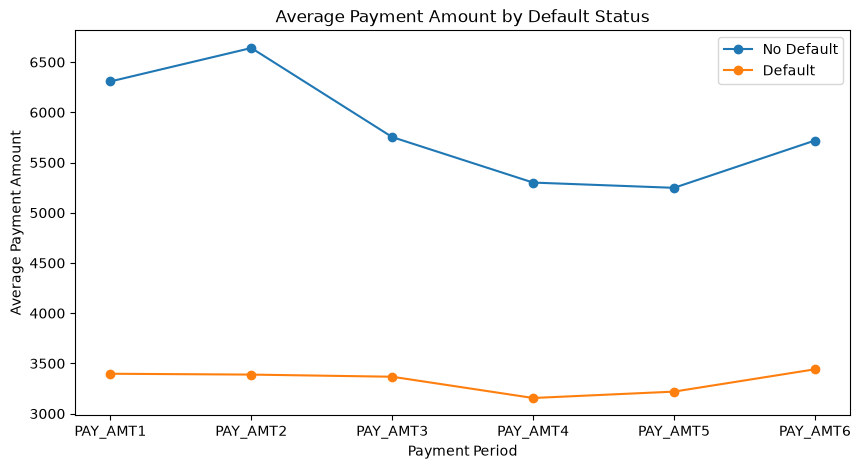

In [46]:
plt.figure(figsize=(10, 5))

plt.plot(
    payment_by_default.index,
    payment_by_default["No Default"],
    marker="o",
    label="No Default"
)

plt.plot(
    payment_by_default.index,
    payment_by_default["Default"],
    marker="o",
    label="Default"
)

plt.title("Average Payment Amount by Default Status")
plt.xlabel("Payment Period")
plt.ylabel("Average Payment Amount")
plt.legend()

plt.show()

### Payment Amount Interpretation

Previous payment amounts show a clear difference between customers who defaulted and those who did not.

Across all six payment periods, non-defaulting customers made substantially larger average payments. For example, the average `PAY_AMT1` payment was approximately 6,307 for non-defaulting customers compared with 3,397 for customers who defaulted.

This pattern remains consistent across all six months, suggesting that lower historical payment amounts are associated with a greater likelihood of future default.

Payment behaviour therefore appears to provide useful predictive information. However, payment amounts should also be considered relative to customers' outstanding bills and credit limits, since the same payment amount may represent very different repayment behaviour for different customers.

## 4. Correlation Analysis

Correlation analysis is used to examine relationships between the numerical variables and identify features that may contain similar information.

Particular attention is given to relationships among repayment status, bill amounts, payment amounts, credit limits, and the target variable.

In [47]:
numeric_df = df.select_dtypes(include="number")

corr_matrix = numeric_df.corr()

target_corr = (
    corr_matrix[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

target_corr

PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
SEX         -0.039961
EDUCATION    0.028006
MARRIAGE    -0.024339
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
ID          -0.013952
AGE          0.013890
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
Name: default payment next month, dtype: float64

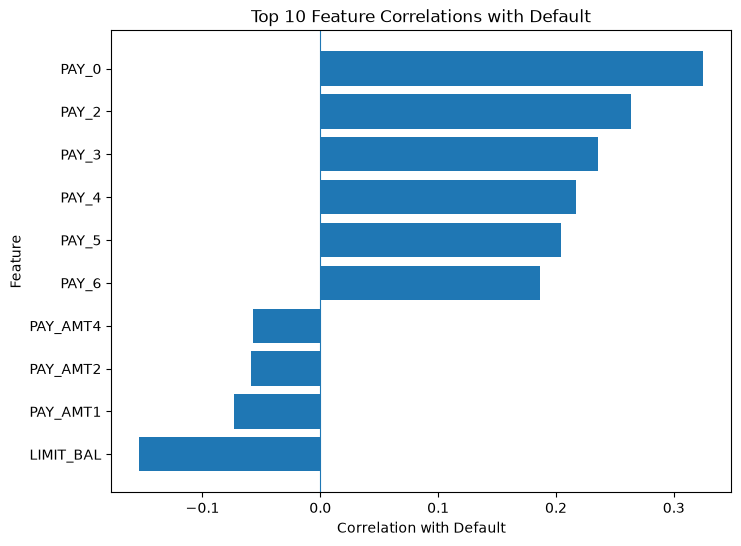

In [48]:
top_corr = target_corr.head(10).sort_values()

plt.figure(figsize=(8, 6))

plt.barh(
    top_corr.index,
    top_corr.values
)

plt.title("Top 10 Feature Correlations with Default")
plt.xlabel("Correlation with Default")
plt.ylabel("Feature")

plt.axvline(0, linewidth=0.8)

plt.show()

In [49]:
target_corr.head(10)

PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
Name: default payment next month, dtype: float64

### Correlation Interpretation

Repayment status variables have the strongest correlations with future default. The most recent repayment status (`PAY_0`) has the strongest positive correlation at approximately 0.325, followed by `PAY_2` (0.264) and `PAY_3` (0.235).

The correlations generally become weaker for older repayment periods, suggesting that more recent payment behaviour may be more informative for predicting future default.

`LIMIT_BAL` has a negative correlation of approximately -0.154 with default, supporting the earlier finding that customers with higher credit limits tend to have lower observed default rates.

Previous payment amounts also have negative correlations with default. Although these correlations are relatively weak, they are consistent with the earlier analysis showing that customers who default tend to make smaller payments.

Overall, repayment-status variables appear to provide the strongest individual signals of default risk among the features examined. However, correlation alone does not capture all potentially useful relationships and should not be used as the sole criterion for feature selection.

## 5. EDA Conclusions

The exploratory analysis identified several important patterns associated with credit card default.

### Key Findings

1. **The target variable is moderately imbalanced.**  
   Approximately 22.12% of customers defaulted, compared with 77.88% who did not. Therefore, model evaluation should not rely on accuracy alone.

2. **Demographic variables show relatively modest relationships with default.**  
   Age, sex, education, and marital status show some variation in default rates, but these differences are generally smaller than those observed for financial and repayment variables.

3. **Credit limit is associated with default risk.**  
   Customers with lower credit limits have substantially higher observed default rates. The default rate decreases from approximately 31.79% in the lowest credit-limit group to 13.80% in the highest group.

4. **Repayment history provides the strongest signal of default.**  
   Customers with previous payment delays consistently show much higher default rates. Recent repayment status is particularly informative, with `PAY_0` having the strongest correlation with the target.

5. **Absolute bill amounts alone do not strongly distinguish defaulters.**  
   Average bill amounts are slightly higher among non-defaulting customers, suggesting that outstanding balance should be considered relative to credit limits and payment behaviour rather than independently.

6. **Previous payment amounts differ substantially between the two groups.**  
   Customers who did not default consistently made larger average payments across all six historical periods.

7. **Recent behaviour appears particularly important.**  
   The correlation between repayment status and default generally decreases for older repayment periods, indicating that recent repayment difficulties may provide stronger information about near-term default risk.

### Implications for Modelling

The modelling stage should give particular attention to repayment-status variables, credit limits, and historical payment behaviour.

Potential engineered features worth investigating include:

- Credit utilisation ratios (`BILL_AMT / LIMIT_BAL`)
- Payment-to-bill ratios
- Number of months with delayed payments
- Maximum repayment delay
- Recent payment behaviour
- Average bill amount
- Average payment amount

Because the target is imbalanced, model performance should be evaluated using metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrices in addition to accuracy.

In [50]:
print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Dataset shape: (30000, 29)
Missing values: 0
Duplicate rows: 0
